In [1]:
import sys
sys.path.append("../src")

In [2]:
from load_data import load_meetings
from preprocess import preprocess_dataframe

df = load_meetings("../data/raw")
df = preprocess_dataframe(df)

ERROR processing .DS_Store: [Errno 20] Not a directory: '../data/raw/.DS_Store/summary.json'


In [3]:
from topic_modeling import TopicModeler

tm = TopicModeler()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
embeddings = tm.generate_embeddings(
    df["clean_summary"].tolist()
)
print(embeddings.shape)

(100, 384)


In [5]:
clusters = tm.cluster_texts(embeddings)

clusters

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [6]:
df["cluster"] = clusters

In [7]:
df[["title", "cluster"]].head()

,title,cluster
0,Competitive Landscape Review,-1
1,Detect Outage - Root Cause Analysis,-1
2,Aegis / Summit Trust - Platform Concerns Discu...,-1
3,Support Case #6977 - Brightpath Commerce Slow ...,-1
4,Aegis / Brightpath Commerce - Detect Module De...,-1


/Users/ramraghu/Documents/devoDevo/Brilio-kosam/01/meeting-intelligence/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


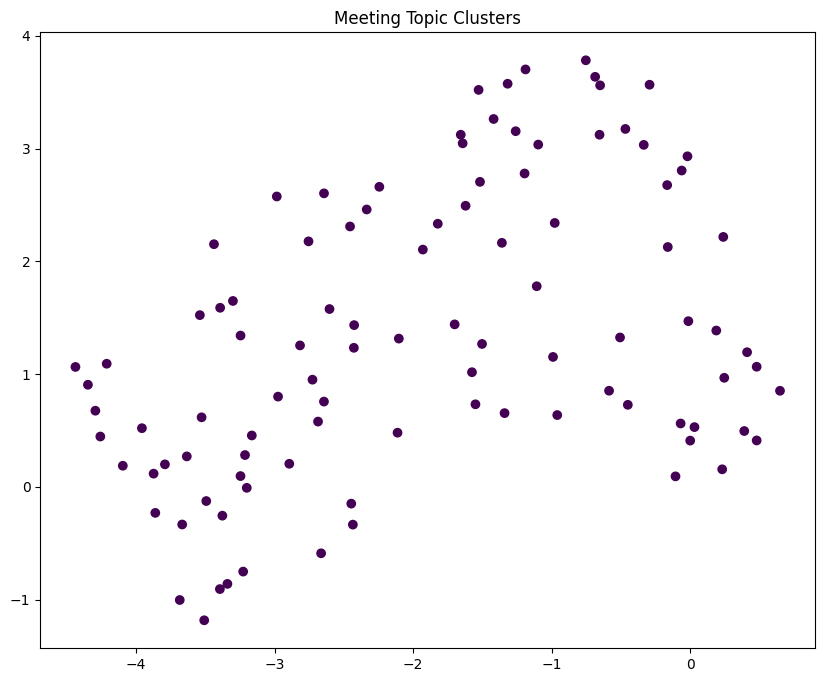

In [8]:
from visualization import plot_umap

plot_umap(embeddings, clusters)

In [9]:
for cluster_id in sorted(df["cluster"].unique()):

    print("\n")
    print("=" * 50)
    print(f"CLUSTER: {cluster_id}")
    print("=" * 50)

    sample = df[df["cluster"] == cluster_id]

    for summary in sample["summary"].head(3):
        print(summary)
        print()



CLUSTER: -1
Jordan Whitfield and Tom Bradley conducted a competitive landscape review in preparation for an upcoming product review meeting. They discussed four key competitors: SentinelShield (threatening Detect with a strong SIEM integration story), VaultEdge (a growing threat to Protect and potentially Comply), CyberNova (aggressive pricing in Identity for mid-market), and Fortiguard Pro (a legacy incumbent). The most pressing concern identified was a gap in the LogVault connector experience compared to SentinelShield, which Jordan plans to surface as a risk item for leadership at next week's review. Jordan agreed to update and share the competitive deck before EOD the following day.

The team conducted a post-incident review of a cascading failure in their event ingestion pipeline that caused six hours of zero threat monitoring visibility for customers. Mike Romano explained that an out-of-memory error on a primary ingestion node triggered a cascade due to the absence of a circui